# **Regularization Ridge Lasso ElasticNet**

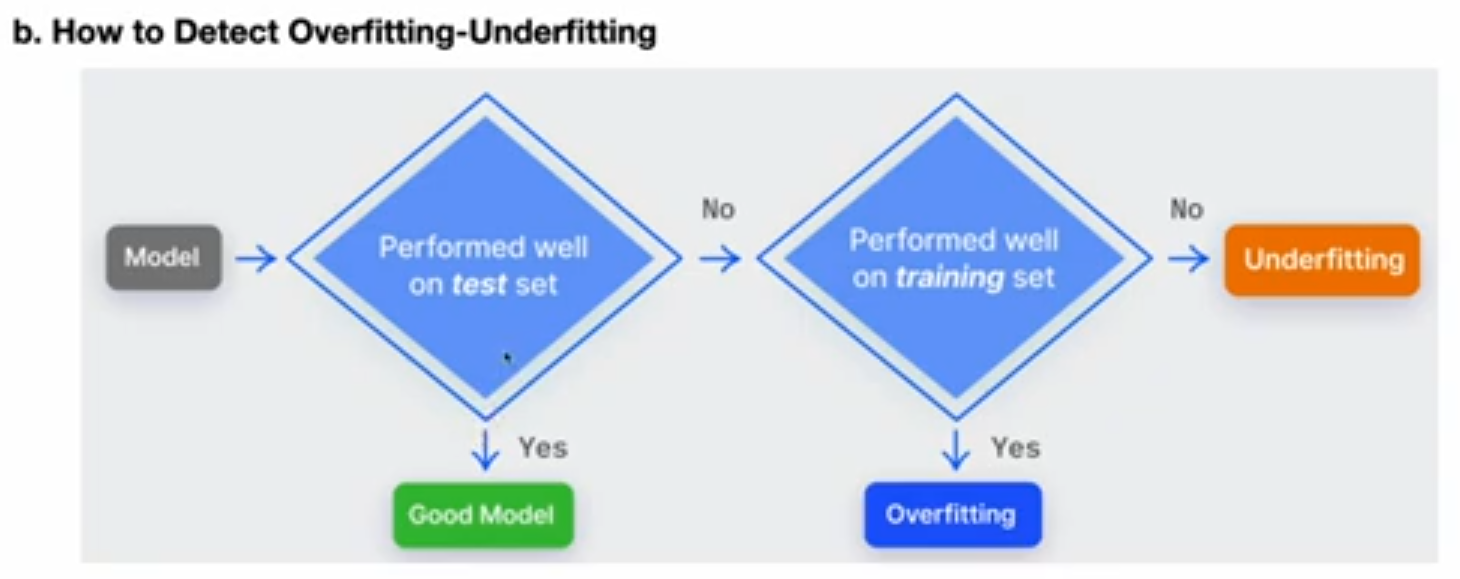

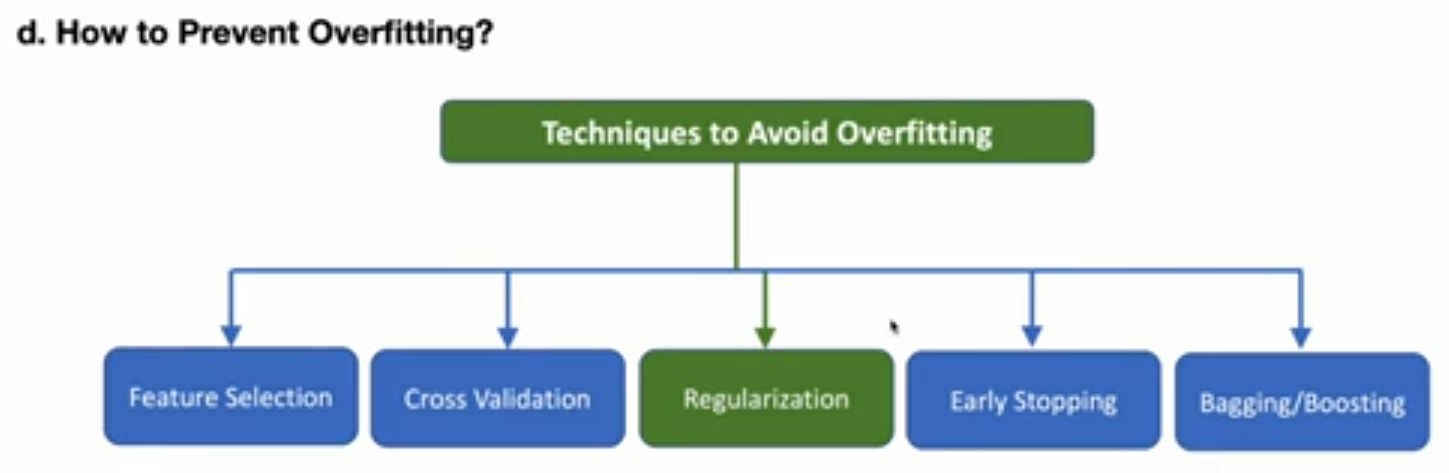

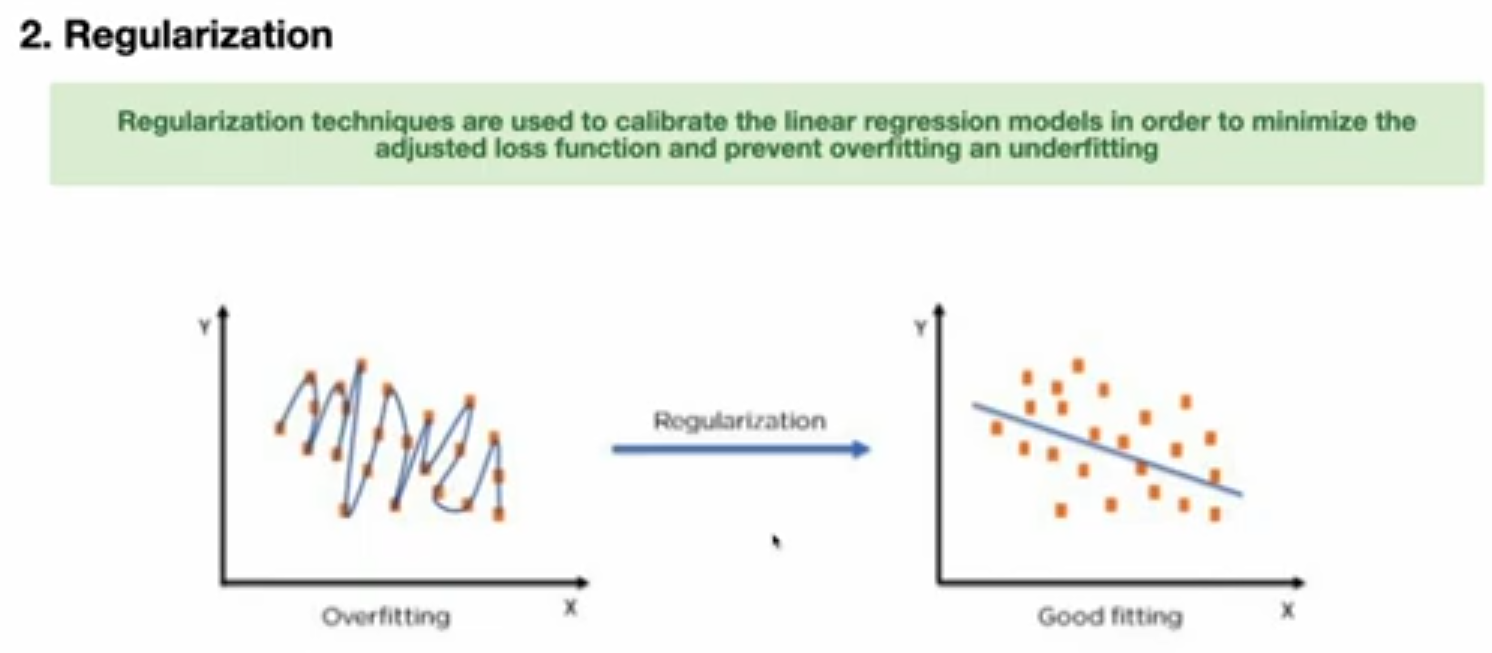

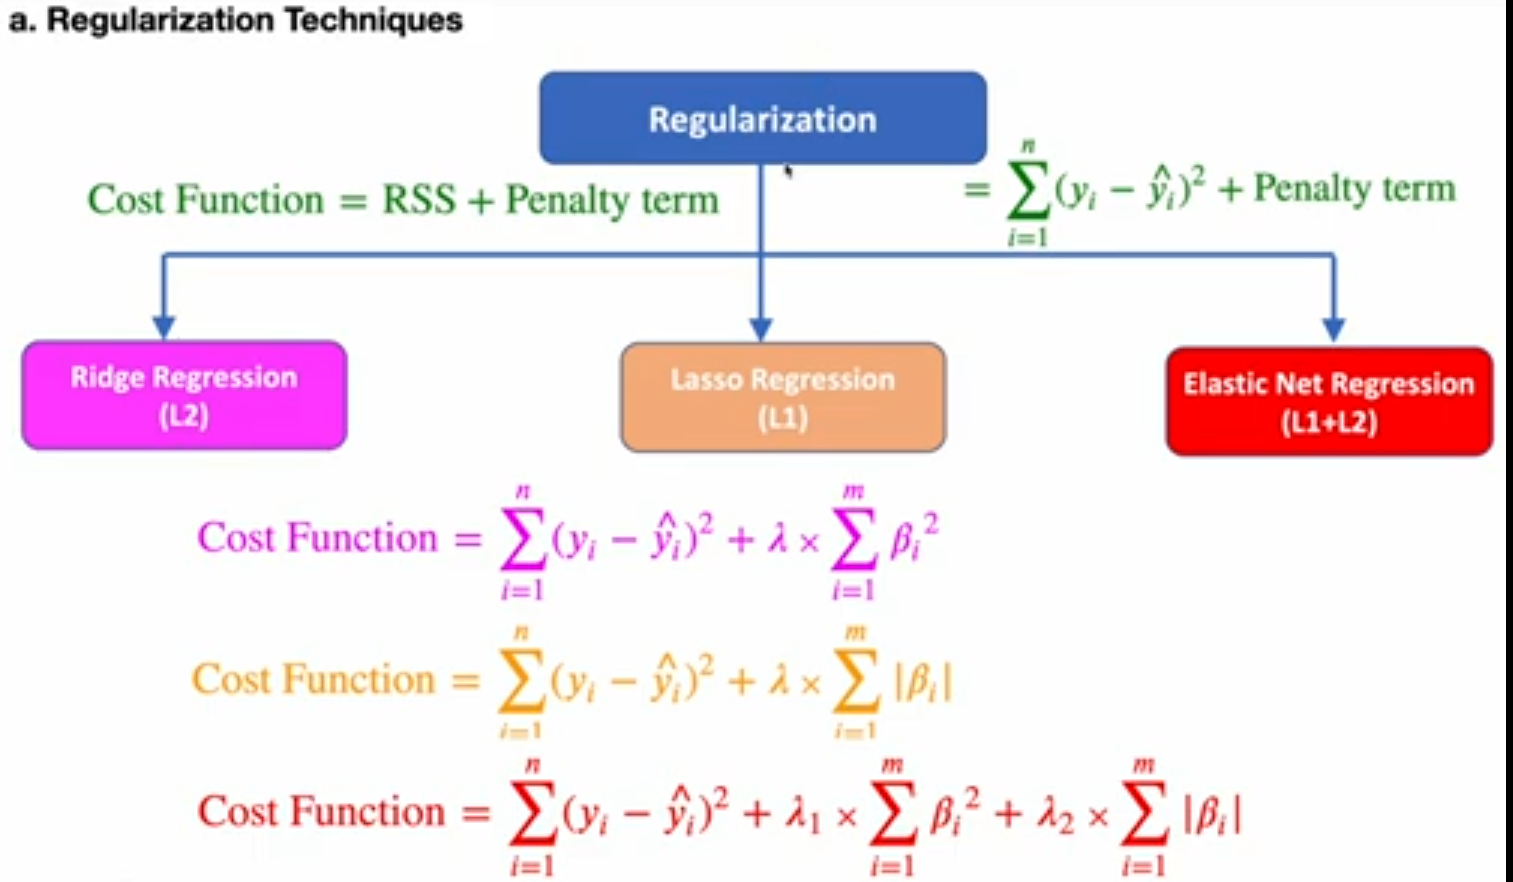

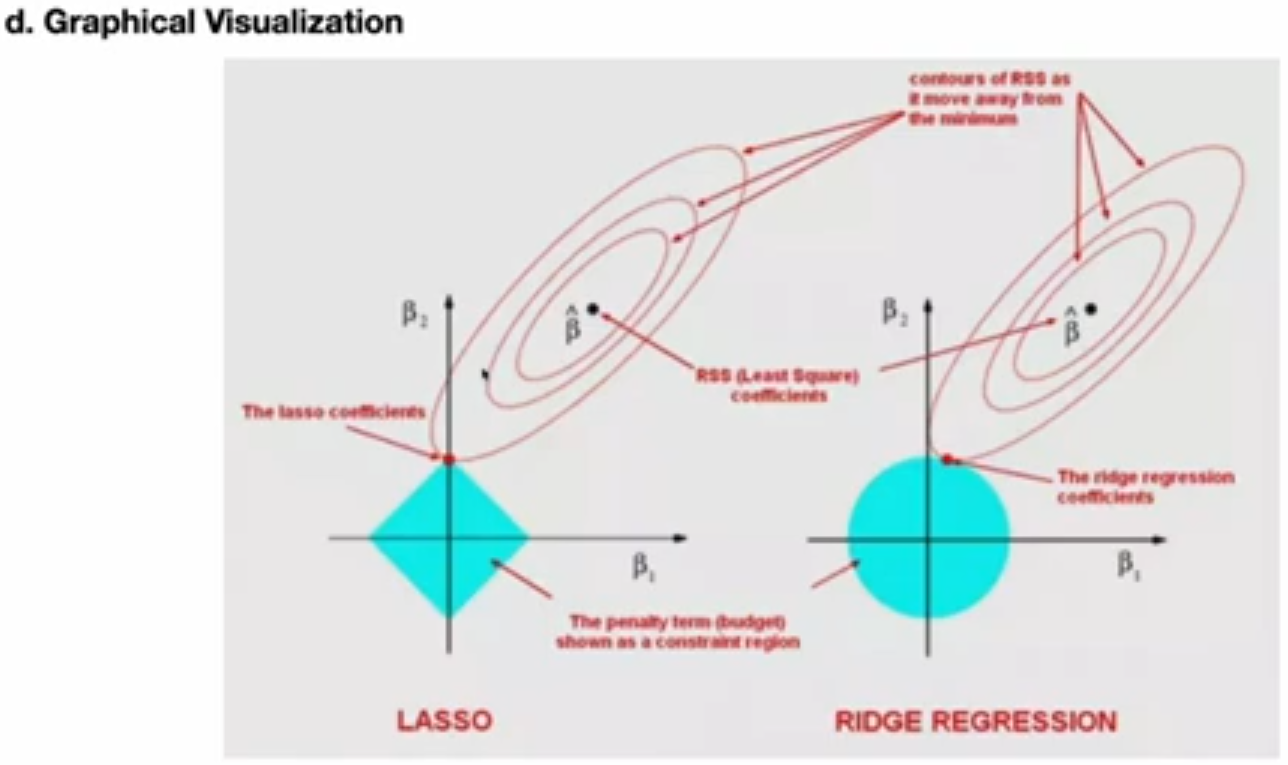

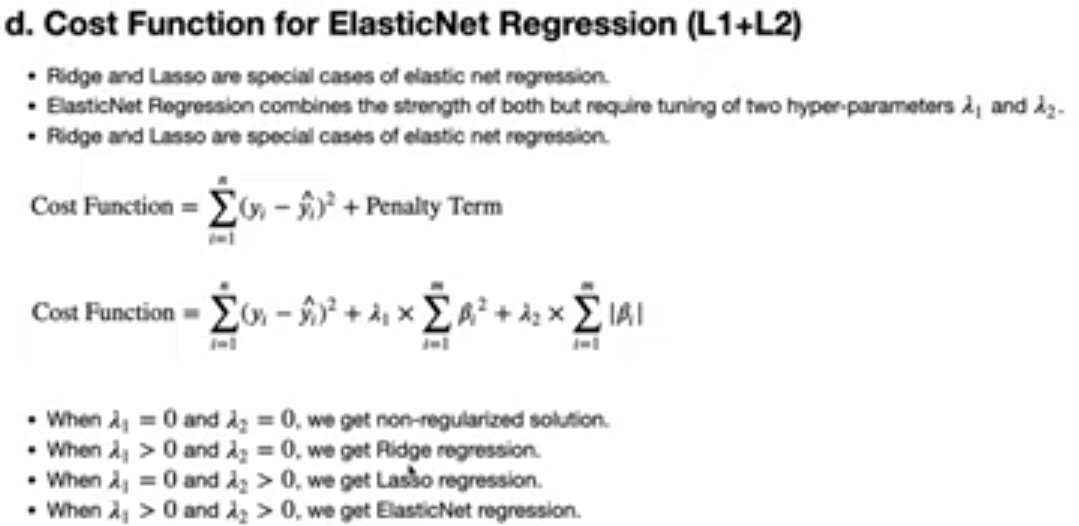

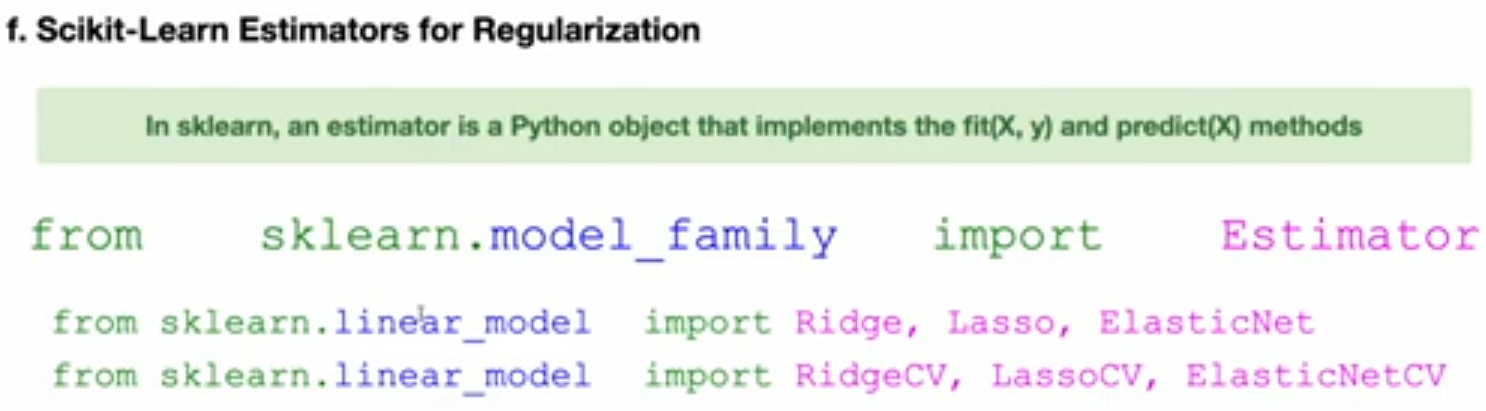

In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

x, y = datasets.make_regression(n_samples=100 , n_features=1, noise=20, n_targets=1, random_state=13)

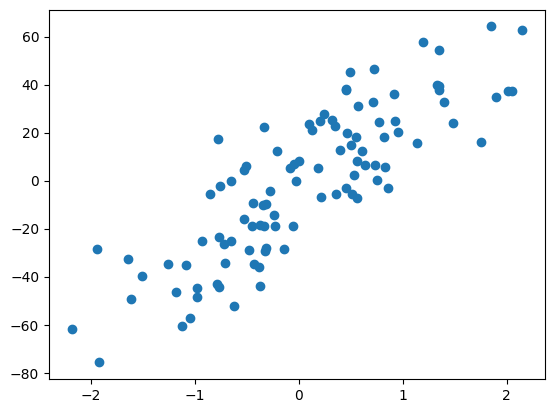

In [2]:
plt.scatter(x,y)

In [12]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x,y)
print("B1: ", lr.coef_)
print("B0: ", lr.intercept_)

B1:  [27.82809103]
B0:  -2.29474455867698


In [13]:
from sklearn.linear_model import Ridge, Lasso
rr1 = Ridge(alpha=0)
rr1.fit(x,y)
print("B1: ", rr1.coef_)
print("B0: ", rr1.intercept_)

B1:  [27.82809103]
B0:  -2.29474455867698


In [14]:
rr2 = Ridge(alpha=10)
rr2.fit(x,y)
print("B1: ", rr2.coef_)
print("B0: ", rr2.intercept_)

B1:  [24.9546267]
B0:  -2.1269130035235735


In [15]:
rr3 = Ridge(alpha=100)
rr3.fit(x,y)
print("B1: ", rr3.coef_)
print("B0: ", rr3.intercept_)

B1:  [12.93442104]
B0:  -1.4248441496033308


In [18]:
ls = Lasso(alpha=100)
ls.fit(x,y)
print("B1: ", ls.coef_)
print("B0: ", ls.intercept_)

B1:  [0.]
B0:  -0.669378360869679


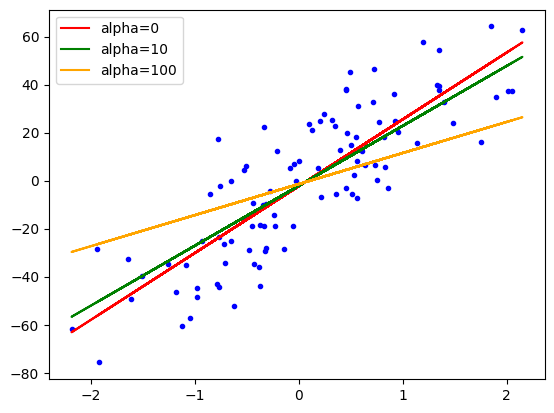

In [17]:
plt.plot(x, y,'b.')
plt.plot(x, rr1.predict(x), color='red', label='alpha=0')
plt.plot(x, rr2.predict(x), color='green', label='alpha=10')
plt.plot(x, rr3.predict(x), color='orange', label='alpha=100')
plt.legend()

In [19]:
import pandas as pd
import numpy as np 
df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\Melbourne_housing.csv")
df.head(5)

,Suburb,Rooms,Type,Method,SellerG,Distance,Regionname,Propertycount,CouncilArea,Bedroom2,Bathroom,Car,Landsize,BuildingArea,Price
0,Abbotsford,2,h,S,Biggin,2.5,Northern Metropolitan,4019.0,Yarra City Council,2.0,1.0,1.0,202.0,160.2564,1480000.0
1,Abbotsford,2,h,S,Biggin,2.5,Northern Metropolitan,4019.0,Yarra City Council,2.0,1.0,0.0,156.0,79.0000,1035000.0
2,Abbotsford,3,h,SP,Biggin,2.5,Northern Metropolitan,4019.0,Yarra City Council,3.0,2.0,0.0,134.0,150.0000,1465000.0
3,Abbotsford,3,h,PI,Biggin,2.5,Northern Metropolitan,4019.0,Yarra City Council,3.0,2.0,1.0,94.0,160.2564,850000.0
4,Abbotsford,4,h,VB,Nelson,2.5,Northern Metropolitan,4019.0,Yarra City Council,3.0,1.0,2.0,120.0,142.0000,1600000.0


In [20]:
df = pd.get_dummies(df, drop_first=True)
df.head(5)

,Rooms,Distance,Propertycount,Bedroom2,Bathroom,Car,Landsize,BuildingArea,Price,Suburb_Aberfeldie,...,CouncilArea_Moorabool Shire Council,CouncilArea_Moreland City Council,CouncilArea_Nillumbik Shire Council,CouncilArea_Port Phillip City Council,CouncilArea_Stonnington City Council,CouncilArea_Whitehorse City Council,CouncilArea_Whittlesea City Council,CouncilArea_Wyndham City Council,CouncilArea_Yarra City Council,CouncilArea_Yarra Ranges Shire Council
0,2,2.5,4019.0,2.0,1.0,1.0,202.0,160.2564,1480000.0,False,...,False,False,False,False,False,False,False,False,True,False
1,2,2.5,4019.0,2.0,1.0,0.0,156.0,79.0000,1035000.0,False,...,False,False,False,False,False,False,False,False,True,False
2,3,2.5,4019.0,3.0,2.0,0.0,134.0,150.0000,1465000.0,False,...,False,False,False,False,False,False,False,False,True,False
3,3,2.5,4019.0,3.0,2.0,1.0,94.0,160.2564,850000.0,False,...,False,False,False,False,False,False,False,False,True,False
4,4,2.5,4019.0,3.0,1.0,2.0,120.0,142.0000,1600000.0,False,...,False,False,False,False,False,False,False,False,True,False


In [23]:
x = df.drop('Price', axis=1)
y = df['Price']
x.shape, y.shape

((27244, 744), (27244,))

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=2)

In [28]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [29]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2 Score on Training Data set: ", lr.score(x_train,y_train))
print("R2 Score on Training Data set: ", r2_score(y_train,lr.predict(x_train)))

R2 Score on Training Data set:  0.6827792395792723
R2 Score on Training Data set:  0.6827792395792723


In [30]:
print("R2 Score on test Data set: ", lr.score(x_test,y_test))
print("R2 Score on test Data set: ", r2_score(y_test,lr.predict(x_test)))

R2 Score on test Data set:  0.13853683161499264
R2 Score on test Data set:  0.13853683161499264


Above model is Overfitting, because it gives good result on training data but bad at testig data.

## **Ridge Linear Regression**

In [31]:
from sklearn.linear_model import Ridge
rr = Ridge(alpha=1)
rr.fit(x_train, y_train)


Ridge(alpha=1)

In [32]:
print("R2 Score on Training Data set: ", rr.score(x_train,y_train))
print("R2 Score on test Data set: ", r2_score(y_train,rr.predict(x_train)))

R2 Score on Training Data set:  0.6796668251040214
R2 Score on test Data set:  0.6796668251040214


In [33]:
print("R2 Score on test Data set: ", rr.score(x_test,y_test))
print("R2 Score on test Data set: ", r2_score(y_test,rr.predict(x_test)))

R2 Score on test Data set:  0.6701765758295284
R2 Score on test Data set:  0.6701765758295284


above model is good becacuses it almost same value on training and testing data. 

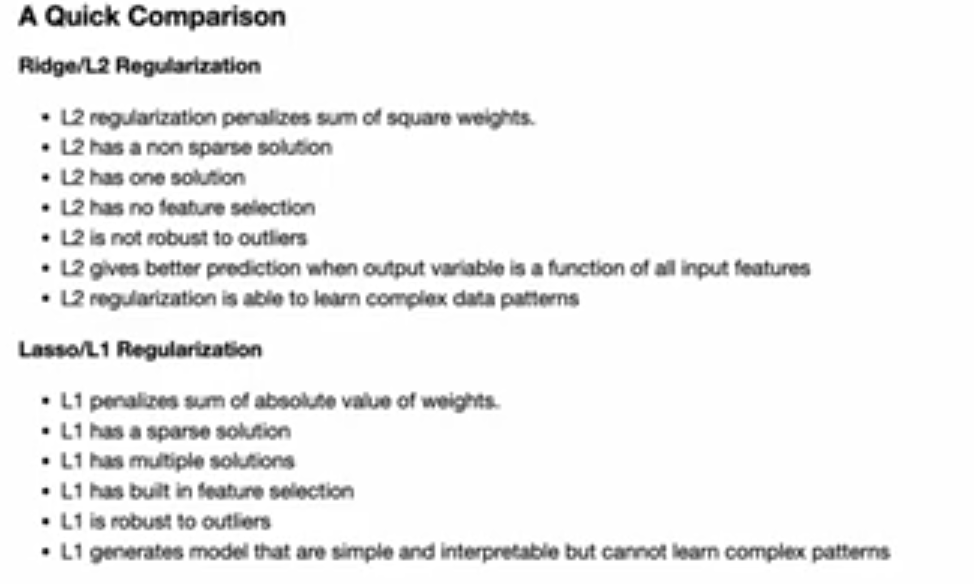

# **New Section # 17**
**Regularization Ridge Lasso ElasticNet**

Techniques to avoid Overfitting

- Feature Selection
- Cross Validation
- Regularization
- Early Stopping
- Bagging/Boosting


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\advertising4D.csv")
X = df.drop('sales', axis=1)
y = df['sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=54)
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error


alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]


for alpha in alphas:
  print(f"Alpha: {alpha}")
  l1 = Lasso(alpha=alpha)
  l2 = Ridge(alpha=alpha)

  l1.fit(X_train, y_train)
  l2.fit(X_train, y_train)

  print("Lasso Regrerssion Score:")
  print("L1 Score on Training Data set: ", l1.score(X_train,y_train))
  print("L1 Score on test Data set: ", r2_score(y_train,l1.predict(X_train)))

  print("Ridge Regrerssion Score:")
  print("L2 Score on Training Data set: ", l2.score(X_train,y_train))
  print("L2 Score on test Data set: ", r2_score(y_train,l2.predict(X_train)),"\n")


Alpha: 0.001
Lasso Regrerssion Score:
L1 Score on Training Data set:  0.8919832929055752
L1 Score on test Data set:  0.8919832929055752
Ridge Regrerssion Score:
L2 Score on Training Data set:  0.8919832932654929
L2 Score on test Data set:  0.8919832932654929 

Alpha: 0.01
Lasso Regrerssion Score:
L1 Score on Training Data set:  0.8919832572804126
L1 Score on test Data set:  0.8919832572804126
Ridge Regrerssion Score:
L2 Score on Training Data set:  0.8919832932654685
L2 Score on test Data set:  0.8919832932654685 

Alpha: 0.1
Lasso Regrerssion Score:
L1 Score on Training Data set:  0.8919796963739518
L1 Score on test Data set:  0.8919796963739518
Ridge Regrerssion Score:
L2 Score on Training Data set:  0.8919832932630445
L2 Score on test Data set:  0.8919832932630445 

Alpha: 1.0
Lasso Regrerssion Score:
L1 Score on Training Data set:  0.891683164459009
L1 Score on test Data set:  0.891683164459009
Ridge Regrerssion Score:
L2 Score on Training Data set:  0.8919832930206542
L2 Score on 

In [10]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

print(f"{'Alpha':<10} {'Model':<10} {'Train R2':<12} {'Test R2':<12}")
print("-" * 50)

for alpha in alphas:
    # Initialize models
    lasso = Lasso(alpha=alpha, max_iter=10000)  # increase max_iter to avoid convergence warnings
    ridge = Ridge(alpha=alpha)

    # Fit models
    lasso.fit(X_train, y_train)
    ridge.fit(X_train, y_train)

    # Predict on train and test
    y_train_lasso_pred = lasso.predict(X_train)
    y_test_lasso_pred = lasso.predict(X_test)

    y_train_ridge_pred = ridge.predict(X_train)
    y_test_ridge_pred = ridge.predict(X_test)

    # Print scores
    print(f"{alpha:<10} {'Lasso':<10} {r2_score(y_train, y_train_lasso_pred):<12.4f} {r2_score(y_test, y_test_lasso_pred):<12.4f}")
    print(f"{alpha:<10} {'Ridge':<10} {r2_score(y_train, y_train_ridge_pred):<12.4f} {r2_score(y_test, y_test_ridge_pred):<12.4f}")


Alpha      Model      Train R2     Test R2     
--------------------------------------------------
0.001      Lasso      0.8920       0.9175      
0.001      Ridge      0.8920       0.9175      
0.01       Lasso      0.8920       0.9175      
0.01       Ridge      0.8920       0.9175      
0.1        Lasso      0.8920       0.9175      
0.1        Ridge      0.8920       0.9175      
1.0        Lasso      0.8917       0.9170      
1.0        Ridge      0.8920       0.9175      
10.0       Lasso      0.8755       0.8916      
10.0       Ridge      0.8920       0.9175      
100.0      Lasso      0.5605       0.5826      
100.0      Ridge      0.8920       0.9174      


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]

# Store scores
lasso_train_scores = []
lasso_test_scores = []
ridge_train_scores = []
ridge_test_scores = []

for alpha in alphas:
    # Initialize models
    lasso = Lasso(alpha=alpha, max_iter=10000)
    ridge = Ridge(alpha=alpha)

    # Fit models
    lasso.fit(X_train_scaled, y_train)
    ridge.fit(X_train_scaled, y_train)

    # Compute R2
    lasso_train_scores.append(r2_score(y_train, lasso.predict(X_train_scaled)))
    lasso_test_scores.append(r2_score(y_test, lasso.predict(X_test_scaled)))

    ridge_train_scores.append(r2_score(y_train, ridge.predict(X_train_scaled)))
    ridge_test_scores.append(r2_score(y_test, ridge.predict(X_test_scaled)))


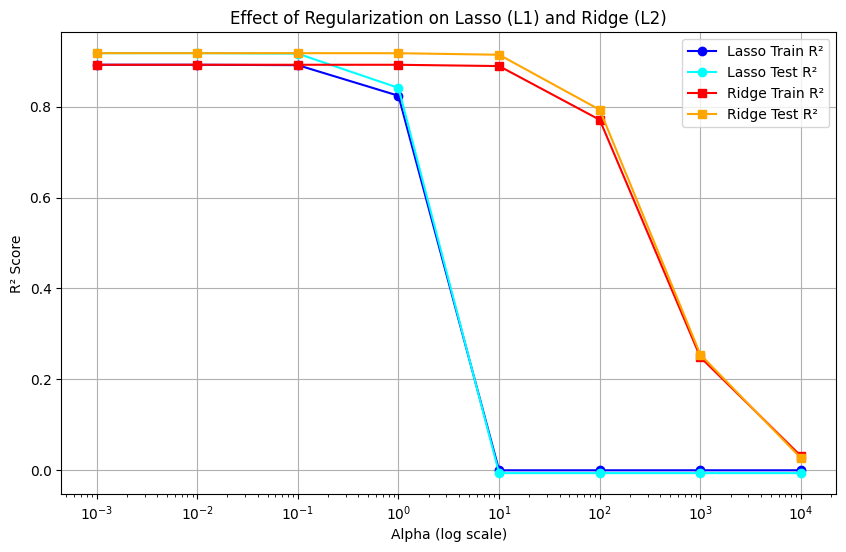

In [12]:

# Plot
plt.figure(figsize=(10,6))
plt.plot(alphas, lasso_train_scores, marker='o', label='Lasso Train R²', color='blue')
plt.plot(alphas, lasso_test_scores, marker='o', label='Lasso Test R²', color='cyan')
plt.plot(alphas, ridge_train_scores, marker='s', label='Ridge Train R²', color='red')
plt.plot(alphas, ridge_test_scores, marker='s', label='Ridge Test R²', color='orange')
plt.xscale('log')  # alpha is logarithmic
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.title('Effect of Regularization on Lasso (L1) and Ridge (L2)')
plt.legend()
plt.grid(True)
plt.show()